In [ ]:
!pip install scikit-learn statsmodels catboost scipy -q

In [ ]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import xml.etree.ElementTree as ET
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from scipy.optimize import curve_fit

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

In [ ]:
def moex_shares(ticker, start, end):
    rows_all, s = [], 0
    while True:
        url = (f"https://iss.moex.com/iss/history/engines/stock/markets/shares"
               f"/boards/TQBR/securities/{ticker}.json?"
               f"from={start}&till={end}&start={s}")
        r = requests.get(url).json()
        rows, cols = r['history']['data'], r['history']['columns']
        if not rows:
            break
        rows_all += rows
        s += len(rows)
    if not rows_all:
        return pd.Series(dtype=float)
    df = pd.DataFrame(rows_all, columns=cols)
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    return df.set_index('TRADEDATE')['CLOSE'].apply(
        pd.to_numeric, errors='coerce').pipe(lambda x: x[x > 0])

def moex_index(start, end):
    rows_all, s = [], 0
    while True:
        url = (f"https://iss.moex.com/iss/history/engines/stock/markets/index"
               f"/boards/SNDX/securities/IMOEX.json?"
               f"from={start}&till={end}&start={s}")
        r = requests.get(url).json()
        rows, cols = r['history']['data'], r['history']['columns']
        if not rows:
            break
        rows_all += rows
        s += len(rows)
    df = pd.DataFrame(rows_all, columns=cols)
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    return df.set_index('TRADEDATE')['CLOSE'].apply(
        pd.to_numeric, errors='coerce').pipe(lambda x: x[x > 0])

def cbr_usd(start, end):
    p1, p2 = start.split('-'), end.split('-')
    d1, d2 = f"{p1[2]}/{p1[1]}/{p1[0]}", f"{p2[2]}/{p2[1]}/{p2[0]}"
    url = (f"https://www.cbr.ru/scripts/XML_dynamic.asp?"
           f"date_req1={d1}&date_req2={d2}&VAL_NM_RQ=R01235")
    root = ET.fromstring(requests.get(url).content)
    recs = [(pd.to_datetime(r.attrib['Date'], dayfirst=True),
             float(r.find('Value').text.replace(',', '.')))
            for r in root.findall('Record')]
    return pd.Series(dict(recs)).sort_index()

In [ ]:
START, END = '2021-01-01', '2025-12-31'
TREATED = 'TCSG'
CONTROLS = ['SBER', 'VTBR', 'YDEX', 'MTSS']
ALL_TICKERS = [TREATED] + CONTROLS

data = {}
old = moex_shares('TCSG', START, END)
new = moex_shares('T', START, END)
data['TCSG'] = pd.concat([old, new]).pipe(
    lambda x: x[~x.index.duplicated(keep='last')]).sort_index()

for t in CONTROLS:
    data[t] = moex_shares(t, START, END)

data['IMOEX'] = moex_index(START, END)
data['USD_RUB'] = cbr_usd(START, END).reindex(data['IMOEX'].index, method='ffill')

prices = pd.DataFrame(data).dropna()
log_rets = np.log(prices / prices.shift(1)).iloc[1:].replace(
    [np.inf, -np.inf], np.nan).dropna()

panel = []
for ticker in ALL_TICKERS:
    tmp = pd.DataFrame({
        'date': log_rets.index,
        'ticker': ticker,
        'ret': log_rets[ticker].values,
        'IMOEX': log_rets['IMOEX'].values,
        'USD_RUB': log_rets['USD_RUB'].values,
    })
    panel.append(tmp)
panel = pd.concat(panel, ignore_index=True)

for w in [5, 20]:
    imoex_roll = log_rets['IMOEX'].rolling(w, min_periods=1)
    vol = imoex_roll.std().values
    mom = imoex_roll.mean().values
    for ticker in ALL_TICKERS:
        mask = panel['ticker'] == ticker
        panel.loc[mask, f'mkt_vol{w}'] = vol
        panel.loc[mask, f'mkt_mom{w}'] = mom

for lag in [1, 2]:
    for ticker in ALL_TICKERS:
        mask = panel['ticker'] == ticker
        panel.loc[mask, f'ret_lag{lag}'] = panel.loc[mask, 'ret'].shift(lag)

panel = panel.dropna().reset_index(drop=True)
print(f"Панель: {len(panel)} строк, {panel['ticker'].nunique()} тикеров, "
      f"{log_rets.index[0].date()} — {log_rets.index[-1].date()}")

Панель: 1830 строк, 5 тикеров, 2024-07-25 — 2025-12-30


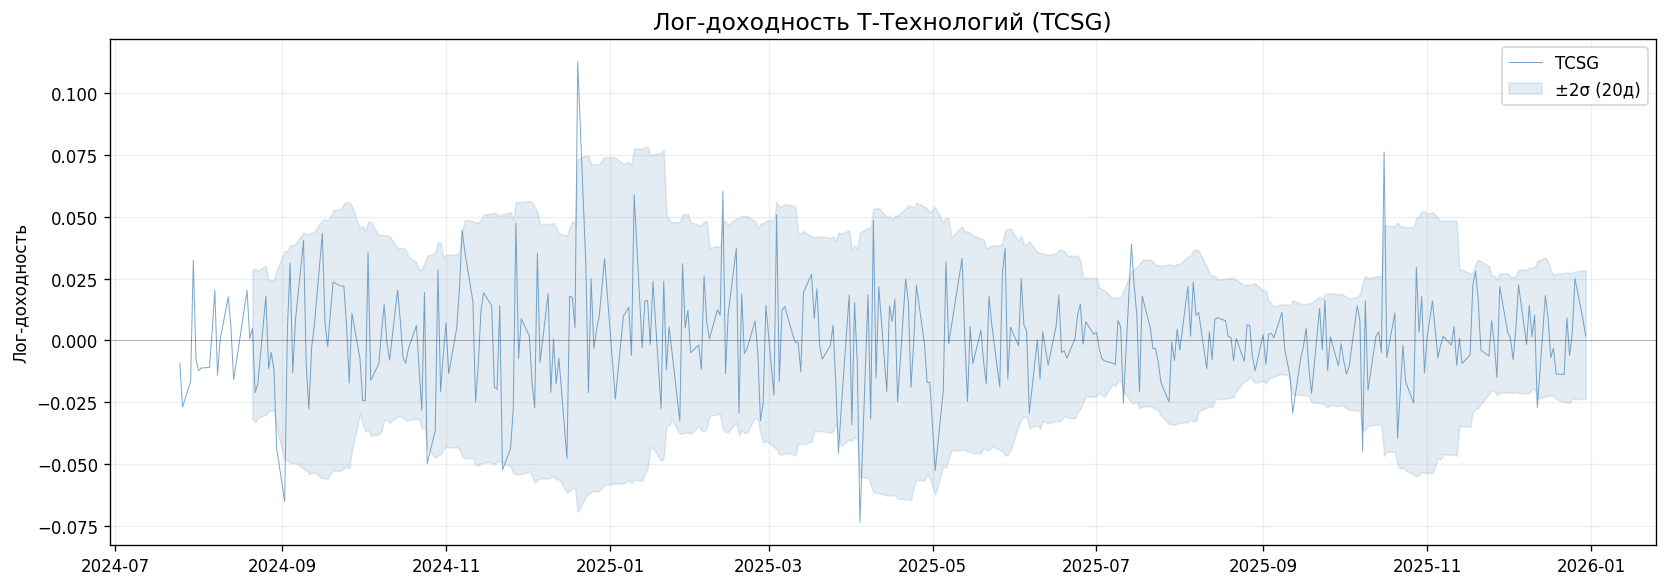

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(log_rets.index, log_rets[TREATED],
        color='steelblue', alpha=0.7, linewidth=0.6, label='TCSG')
ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)

rm = log_rets[TREATED].rolling(20).mean()
rs = log_rets[TREATED].rolling(20).std()
ax.fill_between(log_rets.index, (rm - 2*rs).values, (rm + 2*rs).values,
                alpha=0.15, color='steelblue', label='±2σ (20д)')

ax.set_title('Лог-доходность Т-Технологий (TCSG)', fontsize=14)
ax.set_ylabel('Лог-доходность')
ax.legend(loc='upper right')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
def find_anomalous_days(log_rets, ticker, top_n=60, min_lookback=20):
    ret = log_rets[ticker].copy()
    roll_mean = ret.rolling(min_lookback, min_periods=min_lookback).mean().shift(1)
    roll_std = ret.rolling(min_lookback, min_periods=min_lookback).std().shift(1)
    z_score = ((ret - roll_mean) / roll_std).dropna()
    abs_z = z_score.abs().sort_values(ascending=False)
    top = abs_z.head(top_n)

    return pd.DataFrame({
        'date': top.index,
        'z_score': z_score.loc[top.index].values,
        'abs_z': top.values,
        'log_ret_TCSG': ret.loc[top.index].values,
        'log_ret_IMOEX': log_rets['IMOEX'].loc[top.index].values,
    }).reset_index(drop=True)

TOP_N = 200
anomalous = find_anomalous_days(log_rets, TREATED, top_n=TOP_N)
print(anomalous[['date', 'z_score', 'log_ret_TCSG', 'log_ret_IMOEX']]
      .head(20).to_string(index=False, float_format='%.4f'))

      date  z_score  log_ret_TCSG  log_ret_IMOEX
2025-10-16   5.3998        0.0763         0.0243
2024-12-20   4.4521        0.1127         0.0879
2025-07-14   3.8936        0.0389         0.0269
2024-09-02  -3.8494       -0.0653        -0.0405
2025-09-12  -3.7566       -0.0294        -0.0238
2025-04-04  -3.7533       -0.0737        -0.0275
2025-10-08  -3.3748       -0.0449        -0.0406
2025-02-12   3.3374        0.0602         0.0025
2024-08-30  -3.1750       -0.0437        -0.0216
2025-07-11  -3.0708       -0.0254        -0.0337
2024-10-25  -2.9170       -0.0498        -0.0216
2025-03-27  -2.6538       -0.0457        -0.0200
2025-12-12  -2.6199       -0.0272        -0.0034
2024-11-07   2.4418        0.0447         0.0104
2024-11-22  -2.1470       -0.0524         0.0048
2025-04-09   2.1225        0.0485        -0.0355
2025-03-04   2.0926        0.0509         0.0300
2024-09-09   2.0584        0.0404         0.0300
2025-11-19   2.0471        0.0280         0.0319
2025-01-27  -2.0364 

In [ ]:
def dml_did_panel(panel, event_date, treated_ticker, controls,
                  pre_window=60, post_window=5, n_folds=5, seed=42):
    all_dates = sorted(panel['date'].unique())
    event_dt = pd.Timestamp(event_date)
    all_dates_arr = np.array(all_dates)
    event_idx = np.searchsorted(all_dates_arr, event_dt)
    event_idx = min(event_idx, len(all_dates_arr) - 1)
    event_td = all_dates_arr[event_idx]

    start_idx = max(0, event_idx - pre_window)
    end_idx = min(len(all_dates_arr) - 1, event_idx + post_window)
    window_dates = set(all_dates_arr[start_idx:end_idx + 1])

    df = panel[panel['date'].isin(window_dates)].copy()
    if len(df) < 50:
        return None

    df['post'] = (df['date'] >= event_td).astype(int)
    df['treated'] = (df['ticker'] == treated_ticker).astype(int)
    df['W'] = df['post'] * df['treated']

    Y = df['ret'].values
    W = df['W'].values.astype(float)

    num_cols = ['IMOEX', 'USD_RUB', 'mkt_vol5', 'mkt_vol20',
                'mkt_mom5', 'mkt_mom20', 'ret_lag1', 'ret_lag2']
    X_num = df[num_cols].values
    ticker_dummies = pd.get_dummies(df['ticker'], drop_first=True).values
    X_did = df[['post', 'treated']].values
    X = np.hstack([X_num, ticker_dummies, X_did])

    mask = np.isfinite(X).all(axis=1) & np.isfinite(Y) & np.isfinite(W)
    if mask.sum() < 30:
        return None
    X, Y, W = X[mask], Y[mask], W[mask]

    scaler = StandardScaler(with_mean=False)
    X[:, :len(num_cols)] = scaler.fit_transform(X[:, :len(num_cols)])

    n = len(Y)
    resid_y = np.zeros(n)
    resid_w = np.zeros(n)

    n_folds_actual = max(2, min(n_folds, n // 10))
    kf = KFold(n_splits=n_folds_actual, shuffle=True, random_state=seed)

    for train_idx, test_idx in kf.split(X):
        my = LinearRegression().fit(X[train_idx], Y[train_idx])
        resid_y[test_idx] = Y[test_idx] - my.predict(X[test_idx])

        mw = LinearRegression().fit(X[train_idx], W[train_idx])
        resid_w[test_idx] = W[test_idx] - mw.predict(X[test_idx])

    denom = np.dot(resid_w, resid_w)
    if denom < 1e-12:
        return None

    theta = np.dot(resid_w, resid_y) / denom
    eps = resid_y - theta * resid_w
    V = np.sum((resid_w ** 2) * (eps ** 2)) / (denom ** 2) * (n / (n - 1))
    se = np.sqrt(V)

    if se < 1e-15:
        return None

    t_stat = theta / se
    p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))

    return {
        'theta': theta, 'se': se, 't_stat': t_stat,
        'p_value': p_value,
        'ci_low': theta - 1.96 * se,
        'ci_high': theta + 1.96 * se,
        'n_obs': n, 'n_post_treated': int(W.sum()),
        'event_td': event_td,
    }

In [ ]:
def placebo_time(panel, event_date, treated_ticker, controls,
                 pre_window=60, post_window=5, n_placebo=5, seed=42):
    all_dates = sorted(panel['date'].unique())
    all_dates_arr = np.array(all_dates)
    event_dt = pd.Timestamp(event_date)
    event_idx = np.searchsorted(all_dates_arr, event_dt)
    event_idx = min(event_idx, len(all_dates_arr) - 1)

    step = post_window * 2 + 5
    results = []
    for k in range(1, n_placebo + 1):
        fake_idx = event_idx - k * step
        if fake_idx < 30:
            break
        fake_date = all_dates_arr[fake_idx]
        r = dml_did_panel(panel, fake_date, treated_ticker, controls,
                          pre_window=min(pre_window, fake_idx),
                          post_window=post_window, seed=seed + k)
        if r is not None:
            results.append(r)
    return results


def placebo_ticker(panel, event_date, treated_ticker, controls,
                   pre_window=60, post_window=5, seed=42):
    results = {}
    all_tickers = [treated_ticker] + controls
    for c in controls:
        other = [x for x in all_tickers if x != c]
        r = dml_did_panel(panel, event_date, c, other,
                          pre_window=pre_window,
                          post_window=post_window, seed=seed)
        results[c] = r
    return results

In [ ]:
PRE_WINDOW = 60
POST_WINDOW = 2
SIGNIFICANCE = 0.05
N_PLACEBO_TIME = 5

all_results = []

for i, row in anomalous.iterrows():
    event_date = row['date']
    z = row['z_score']

    main = dml_did_panel(panel, event_date, TREATED, CONTROLS,
                         pre_window=PRE_WINDOW, post_window=POST_WINDOW)
    if main is None:
        continue

    theta, se, p_val = main['theta'], main['se'], main['p_value']

    plc_t = placebo_time(panel, event_date, TREATED, CONTROLS,
                         pre_window=PRE_WINDOW, post_window=POST_WINDOW,
                         n_placebo=N_PLACEBO_TIME)
    plc_time_pass = True
    n_plc_sig = 0
    if plc_t:
        n_plc_sig = sum(1 for r in plc_t if r['p_value'] < SIGNIFICANCE)
        plc_time_pass = (n_plc_sig / len(plc_t)) < 0.5

    plc_tk = placebo_ticker(panel, event_date, TREATED, CONTROLS,
                            pre_window=PRE_WINDOW, post_window=POST_WINDOW)
    plc_tick_pass = True
    n_ctrl_sig = 0
    ctrl_effects = {}
    for c, r in plc_tk.items():
        if r is not None:
            ctrl_effects[c] = r['theta']
            if r['p_value'] < SIGNIFICANCE:
                n_ctrl_sig += 1
    if ctrl_effects:
        plc_tick_pass = (n_ctrl_sig / len(ctrl_effects)) < 0.5

    all_results.append({
        'date': event_date, 'z_score': z,
        'log_ret_TCSG': row['log_ret_TCSG'],
        'log_ret_IMOEX': row['log_ret_IMOEX'],
        'theta': theta, 'se': se, 't_stat': main['t_stat'],
        'p_value': p_val,
        'ci_low': main['ci_low'], 'ci_high': main['ci_high'],
        'significant': p_val < SIGNIFICANCE,
        'placebo_time_pass': plc_time_pass,
        'placebo_ticker_pass': plc_tick_pass,
        'n_plc_time_sig': n_plc_sig,
        'n_plc_time_total': len(plc_t),
        'n_ctrl_sig': n_ctrl_sig,
        'ctrl_effects': ctrl_effects,
    })

    if (i + 1) % 20 == 0:
        print(f"  [{i+1}/{len(anomalous)}]")

print(f"Оценено: {len(all_results)} событий")

  [20/200]
  [40/200]
  [60/200]
  [80/200]
  [100/200]
  [120/200]
  [140/200]
  [160/200]
  [180/200]
  [200/200]
Оценено: 200 событий


In [ ]:
results_df = pd.DataFrame(all_results)

display_cols = ['date', 'z_score', 'log_ret_TCSG', 'theta', 'se',
                't_stat', 'p_value', 'ci_low', 'ci_high',
                'significant', 'placebo_time_pass', 'placebo_ticker_pass']

n_total = len(results_df)
n_sig = results_df['significant'].sum()

robust = results_df[
    results_df['significant'] &
    results_df['placebo_time_pass'] &
    results_df['placebo_ticker_pass']
].sort_values('date').reset_index(drop=True)

print(f"Всего: {n_total}, значимых: {n_sig}, робастных: {len(robust)}")
print(f"Средний |theta|: {robust['theta'].abs().mean():.5f}")
print(f"theta > 0: {(robust['theta'] > 0).sum()},  theta < 0: {(robust['theta'] < 0).sum()}")
robust[display_cols]

Всего: 200, значимых: 24, робастных: 21
Средний |theta|: 0.01616
theta > 0: 13,  theta < 0: 8


,date,z_score,log_ret_TCSG,theta,se,t_stat,p_value,ci_low,ci_high,significant,placebo_time_pass,placebo_ticker_pass
0,2024-08-23,-0.997839,-0.017630,-0.011493,0.005151,-2.231271,0.025663,-0.021588,-0.001397,True,True,True
1,2024-09-19,0.569755,0.011196,0.011337,0.004148,2.733189,0.006272,0.003207,0.019467,True,True,True
2,2024-09-20,0.987764,0.023606,0.018066,0.004445,4.064136,0.000048,0.009353,0.026778,True,True,True
3,2024-09-23,0.832229,0.021902,0.015571,0.005888,2.644418,0.008183,0.004030,0.027113,True,True,True
4,2024-11-06,1.295798,0.021032,0.020361,0.006699,3.039508,0.002370,0.007232,0.033491,True,True,True
5,2024-11-07,2.441778,0.044657,0.017332,0.007886,2.197734,0.027968,0.001875,0.032789,True,True,True
6,2024-11-14,0.542593,0.011816,0.017662,0.005900,2.993726,0.002756,0.006098,0.029225,True,True,True
7,2024-11-15,0.798381,0.019234,0.019167,0.005044,3.799816,0.000145,0.009280,0.029054,True,True,True
8,2024-11-18,0.533439,0.014035,0.017731,0.008448,2.098863,0.035829,0.001173,0.034290,True,True,True
9,2024-11-22,-2.147042,-0.052430,-0.024638,0.008479,-2.905855,0.003663,-0.041256,-0.008020,True,True,True


In [ ]:
results_df.to_csv('tcsg_all_events_dml_did.csv', index=False)
if len(robust) > 0:
    robust[['date', 'z_score', 'log_ret_TCSG', 'log_ret_IMOEX',
            'theta', 'se', 't_stat', 'p_value', 'ci_low', 'ci_high']
    ].to_csv('tcsg_robust_events_dml_did.csv', index=False)

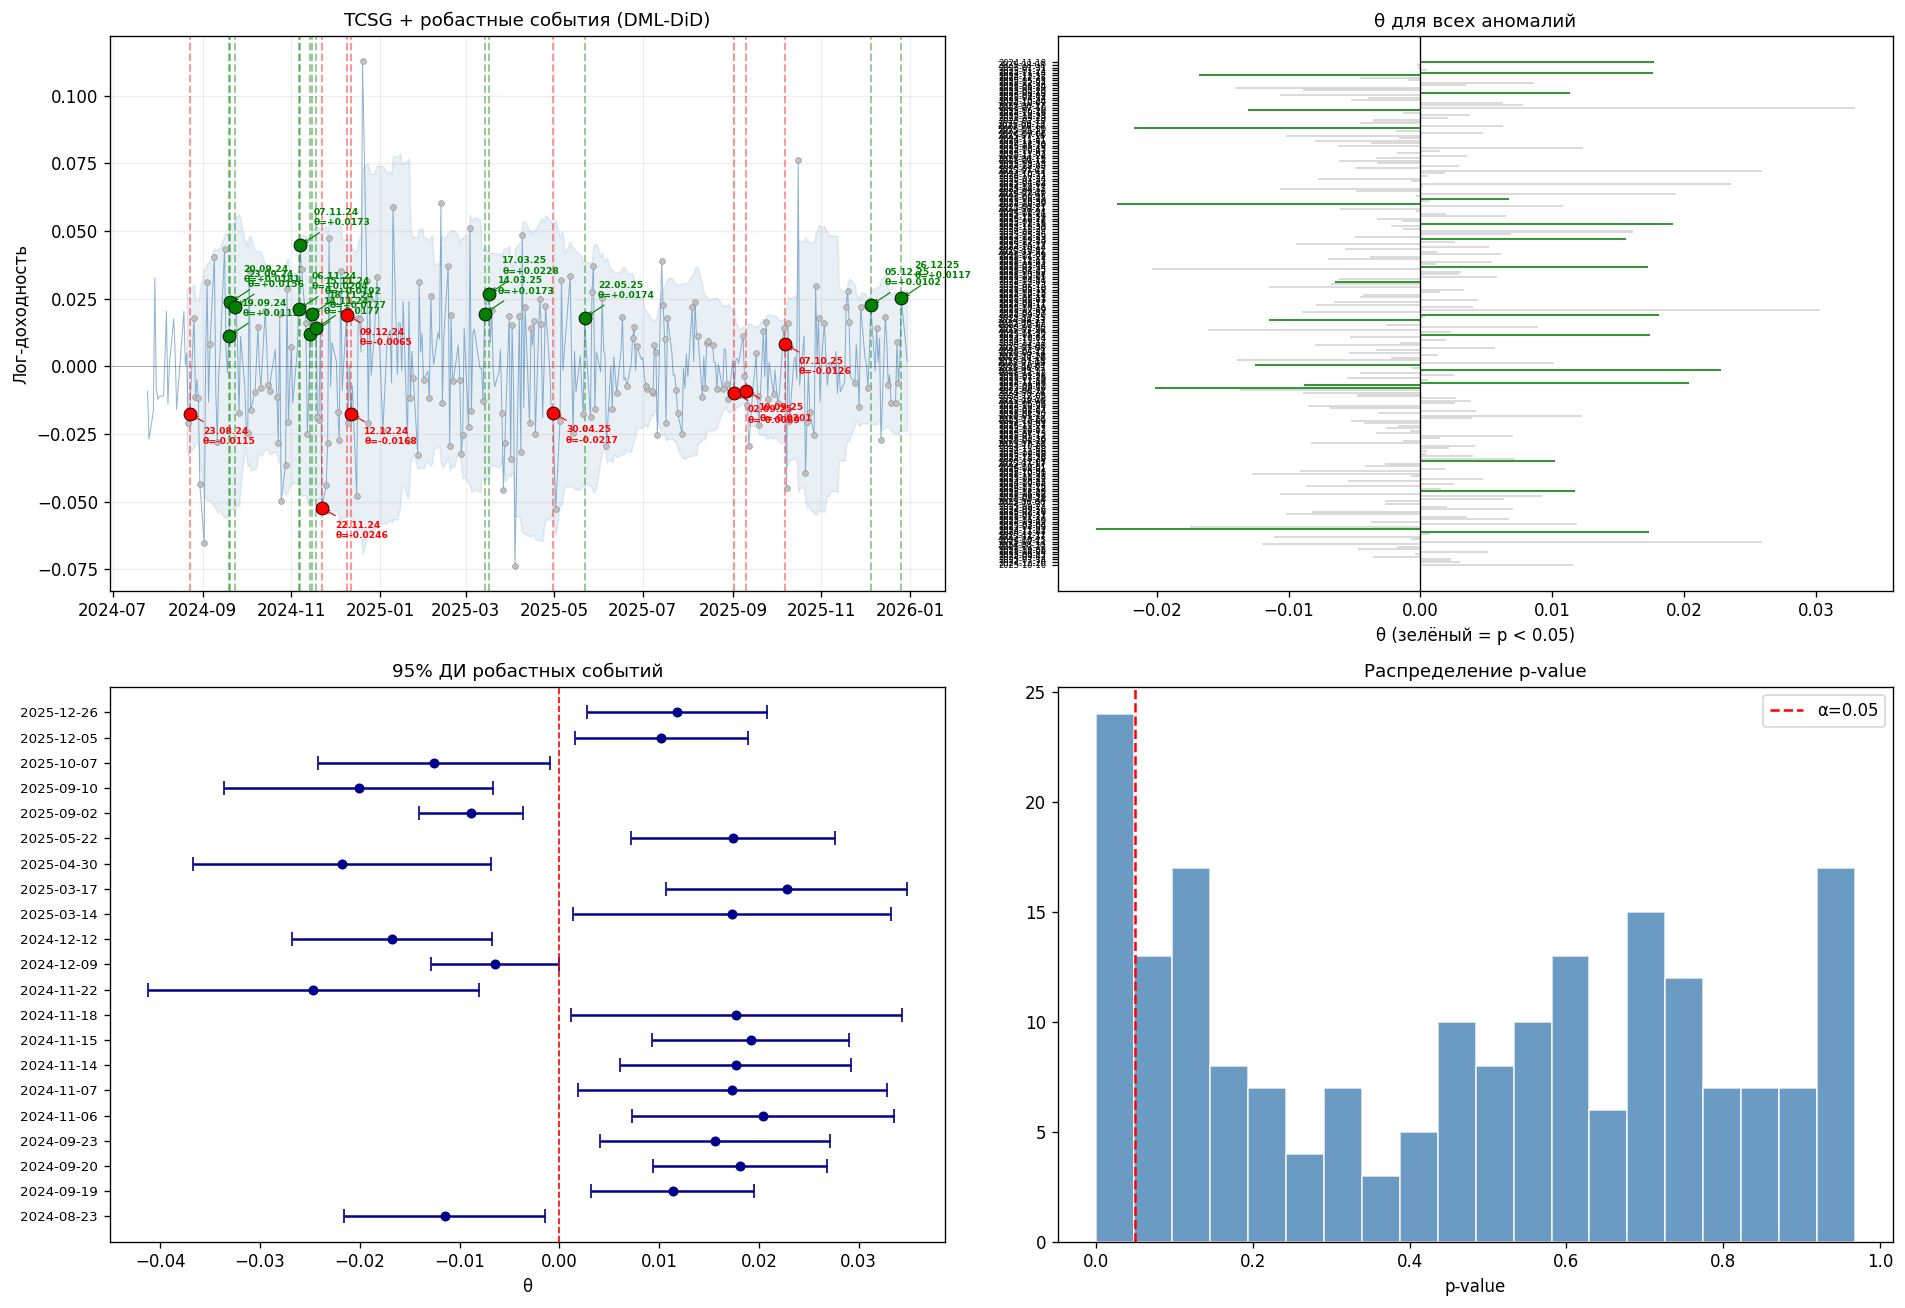

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

ax = axes[0, 0]
ax.plot(log_rets.index, log_rets[TREATED], color='steelblue', alpha=0.6, lw=0.6)
ax.axhline(0, color='black', lw=0.5, alpha=0.3)
ax.fill_between(log_rets.index, (rm-2*rs).values, (rm+2*rs).values,
                alpha=0.12, color='steelblue')
for _, row in anomalous.iterrows():
    ax.scatter(row['date'], row['log_ret_TCSG'],
               color='silver', s=12, zorder=3, edgecolors='gray', lw=0.3)
if len(robust) > 0:
    for _, ev in robust.iterrows():
        c = 'green' if ev['theta'] > 0 else 'red'
        ax.axvline(ev['date'], color=c, alpha=0.4, lw=1.2, ls='--')
        ax.scatter(ev['date'], ev['log_ret_TCSG'], color=c, s=60,
                   zorder=5, edgecolors='black', lw=0.5)
        ax.annotate(f"{ev['date'].strftime('%d.%m.%y')}\nθ={ev['theta']:+.4f}",
                    xy=(ev['date'], ev['log_ret_TCSG']), fontsize=5.5,
                    xytext=(8, 12 if ev['theta'] > 0 else -18),
                    textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color=c, lw=0.7),
                    color=c, fontweight='bold')
ax.set_title('TCSG + робастные события (DML-DiD)', fontsize=11)
ax.set_ylabel('Лог-доходность')
ax.grid(alpha=0.2)

ax = axes[0, 1]
if len(results_df) > 0:
    colors = ['green' if s else 'lightgray' for s in results_df['significant']]
    ax.barh(range(len(results_df)), results_df['theta'], color=colors, alpha=0.8)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_yticks(range(len(results_df)))
    ax.set_yticklabels([d.strftime('%Y-%m-%d') for d in results_df['date']], fontsize=5)
    ax.set_title('θ для всех аномалий', fontsize=11)
    ax.set_xlabel('θ (зелёный = p < 0.05)')

ax = axes[1, 0]
if len(robust) > 0:
    y = range(len(robust))
    ax.errorbar(robust['theta'].values, list(y),
                xerr=[robust['theta'].values - robust['ci_low'].values,
                      robust['ci_high'].values - robust['theta'].values],
                fmt='o', color='darkblue', capsize=4, markersize=5)
    ax.axvline(0, color='red', ls='--', lw=1)
    ax.set_yticks(list(y))
    ax.set_yticklabels([d.strftime('%Y-%m-%d') for d in robust['date']], fontsize=8)
    ax.set_title('95% ДИ робастных событий', fontsize=11)
    ax.set_xlabel('θ')

ax = axes[1, 1]
if len(results_df) > 0:
    ax.hist(results_df['p_value'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0.05, color='red', ls='--', lw=1.5, label='α=0.05')
    ax.set_title('Распределение p-value', fontsize=11)
    ax.set_xlabel('p-value')
    ax.legend()

plt.tight_layout()
plt.show()

# Модель затухания

In [ ]:
def dynamic_did_panel(panel, event_date, treated_ticker, controls,
                      pre_window=80, post_max=20, n_folds=5, seed=42):
    all_dates = sorted(panel['date'].unique())
    all_dates_arr = np.array(all_dates)
    event_dt = pd.Timestamp(event_date)
    event_idx = np.searchsorted(all_dates_arr, event_dt)
    event_idx = min(event_idx, len(all_dates_arr) - 1)
    event_td = all_dates_arr[event_idx]
    start_idx = max(0, event_idx - pre_window)
    pre_dates = set(all_dates_arr[start_idx:event_idx])

    num_cols = ['IMOEX', 'USD_RUB', 'mkt_vol5', 'mkt_vol20',
                'mkt_mom5', 'mkt_mom20', 'ret_lag1', 'ret_lag2']
    num_cols = [c for c in num_cols if c in panel.columns]

    results = {}

    for tau in range(0, post_max + 1):
        target_idx = event_idx + tau
        if target_idx >= len(all_dates_arr):
            break

        target_date = all_dates_arr[target_idx]
        use_dates = pre_dates | {target_date}
        df = panel[panel['date'].isin(use_dates)].copy()

        if len(df) < 30:
            continue

        df['treated'] = (df['ticker'] == treated_ticker).astype(int)
        df['is_post'] = (df['date'] == target_date).astype(int)
        df['W'] = df['treated'] * df['is_post']

        Y = df['ret'].values
        W = df['W'].values.astype(float)

        X_num = df[num_cols].values
        X_did = df[['is_post', 'treated']].values
        ticker_dummies = pd.get_dummies(df['ticker'], drop_first=True).values
        X = np.hstack([X_num, X_did, ticker_dummies])

        mask = np.isfinite(X).all(axis=1) & np.isfinite(Y) & np.isfinite(W)
        if mask.sum() < 20:
            continue
        X_m, Y_m, W_m = X[mask], Y[mask], W[mask]

        if W_m.sum() < 1:
            continue

        n = len(Y_m)
        resid_y = np.zeros(n)
        resid_w = np.zeros(n)

        n_folds_actual = max(2, min(n_folds, n // 10))
        kf = KFold(n_splits=n_folds_actual, shuffle=True,
                    random_state=seed + tau)

        for train_idx, test_idx in kf.split(X_m):
            my = LinearRegression().fit(X_m[train_idx], Y_m[train_idx])
            resid_y[test_idx] = Y_m[test_idx] - my.predict(X_m[test_idx])
            mw = LinearRegression().fit(X_m[train_idx], W_m[train_idx])
            resid_w[test_idx] = W_m[test_idx] - mw.predict(X_m[test_idx])

        denom = np.dot(resid_w, resid_w)
        if denom < 1e-12:
            continue

        theta = np.dot(resid_w, resid_y) / denom
        eps = resid_y - theta * resid_w
        V = np.sum((resid_w ** 2) * (eps ** 2)) / (denom ** 2) * (n / (n - 1))
        se = np.sqrt(max(V, 1e-20))
        t_stat = theta / se
        p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))

        results[tau] = {
            'theta': theta, 'se': se, 't_stat': t_stat,
            'p_value': p_value,
            'ci_low': theta - 1.96 * se,
            'ci_high': theta + 1.96 * se,
        }

    return results

In [ ]:
POST_MAX = 20

all_dynamics = []

for i, row in robust.iterrows():
    base_date = row['date']
    all_dates_arr = np.array(sorted(panel['date'].unique()))
    base_idx = np.searchsorted(all_dates_arr, pd.Timestamp(base_date))

    for tau in range(0, POST_MAX + 1):
        shifted_idx = base_idx + tau
        if shifted_idx >= len(all_dates_arr):
            break

        shifted_date = all_dates_arr[shifted_idx]
        res = dml_did_panel(panel, shifted_date, TREATED, CONTROLS,
                            pre_window=PRE_WINDOW, post_window=POST_WINDOW)
        if res is None:
            continue

        all_dynamics.append({
            'event_date': base_date, 'tau': tau,
            'shifted_date': shifted_date,
            'theta': res['theta'], 'se': res['se'],
            't_stat': res['t_stat'], 'p_value': res['p_value'],
            'ci_low': res['ci_low'], 'ci_high': res['ci_high'],
        })

dynamics_df = pd.DataFrame(all_dynamics)
dynamics_df['theta_abs'] = dynamics_df['theta'].abs()
dynamics_df['significant'] = dynamics_df['p_value'] < SIGNIFICANCE

print(f"Точек: {len(dynamics_df)}, событий: {dynamics_df['event_date'].nunique()}")

Точек: 420, событий: 21


In [ ]:
event_signs = dynamics_df[dynamics_df['tau'] == 0][['event_date', 'theta']].copy()
event_signs['direction'] = np.where(event_signs['theta'] > 0, 'positive', 'negative')
dynamics_df = dynamics_df.merge(
    event_signs[['event_date', 'direction']], on='event_date', how='left')

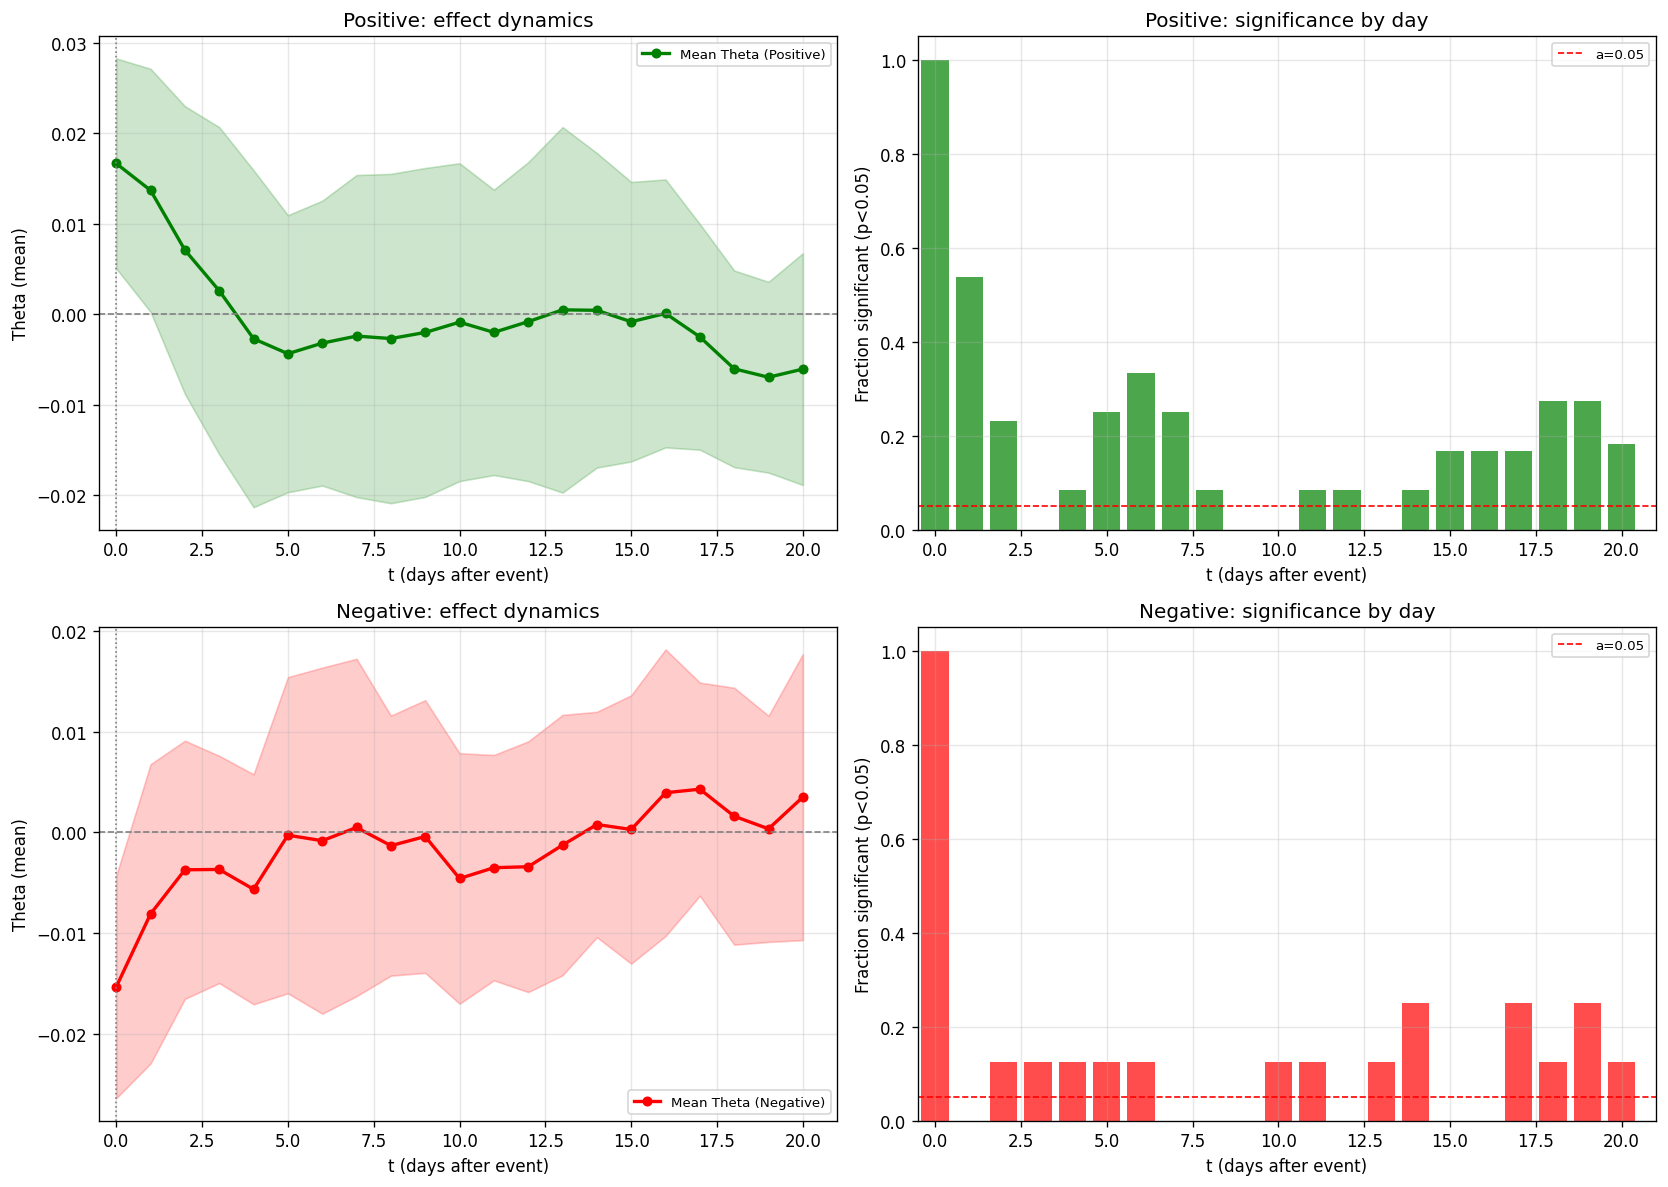

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (direction, color) in enumerate([('positive', 'green'), ('negative', 'red')]):
    sub = dynamics_df[dynamics_df['direction'] == direction]

    avg = sub.groupby('tau').agg(
        theta_mean=('theta', 'mean'),
        se_mean=('se', 'mean'),
        frac_sig=('significant', 'mean'),
    ).reset_index()

    title_dir = 'Positive' if direction == 'positive' else 'Negative'

    # (a) средний Theta
    ax = axes[row, 0]
    ax.plot(avg['tau'], avg['theta_mean'], 'o-', color=color, lw=2, ms=5,
            label=f'Mean Theta ({title_dir})')
    ax.fill_between(avg['tau'],
                    avg['theta_mean'] - 1.96 * avg['se_mean'],
                    avg['theta_mean'] + 1.96 * avg['se_mean'],
                    alpha=0.2, color=color)
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.axvline(0, color='gray', ls=':', lw=1)
    ax.set_xlabel('t (days after event)')
    ax.set_ylabel('Theta (mean)')
    ax.set_title(f'{title_dir}: effect dynamics')
    ax.set_xlim(-0.5, 21)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # (b) доля значимых
    ax = axes[row, 1]
    ax.bar(avg['tau'], avg['frac_sig'], color=color, alpha=0.7)
    ax.axhline(0.05, color='red', ls='--', lw=1, label='a=0.05')
    ax.set_xlabel('t (days after event)')
    ax.set_ylabel('Fraction significant (p<0.05)')
    ax.set_title(f'{title_dir}: significance by day')
    ax.set_xlim(-0.5, 21)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
FIT_HORIZON = 8

def model_exp_decay(t, theta0, lam):
    return theta0 * np.exp(-lam * t)

def bootstrap_decay_by_events(sub_df, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    events = sub_df['event_date'].unique()
    n_events = len(events)

    boot_params = []
    for _ in range(n_boot):
        boot_events = rng.choice(events, size=n_events, replace=True)
        boot_data = pd.concat([
            sub_df[sub_df['event_date'] == e] for e in boot_events
        ])
        boot_data = boot_data[boot_data['tau'] <= FIT_HORIZON]
        avg_boot = boot_data.groupby('tau')['theta'].mean()
        tau_b = avg_boot.index.values.astype(float)
        theta_b = avg_boot.values

        direction = 'positive' if theta_b[0] > 0 else 'negative'
        if direction == 'positive':
            bounds = ([0.0001, 0.01], [0.1, 10.0])
        else:
            bounds = ([-0.1, 0.01], [-0.0001, 10.0])

        try:
            popt_b, _ = curve_fit(model_exp_decay, tau_b, theta_b,
                                  p0=[theta_b[0], 0.5],
                                  bounds=bounds, maxfev=5000)
            boot_params.append(popt_b)
        except:
            continue

    return np.array(boot_params)


fit_by_direction = {}

for direction in ['positive', 'negative']:
    sub = dynamics_df[dynamics_df['direction'] == direction].copy()
    n_events = sub['event_date'].nunique()
    if n_events < 3:
        continue

    avg_dir = sub.groupby('tau').agg(
        theta_mean=('theta', 'mean'),
        theta_se=('theta', lambda x: x.std() / np.sqrt(len(x))),
    ).reset_index()

    avg_fit = avg_dir[avg_dir['tau'] <= FIT_HORIZON]
    tau_d = avg_fit['tau'].values.astype(float)
    theta_d = avg_fit['theta_mean'].values

    if direction == 'positive':
        bounds = ([0.0001, 0.01], [0.1, 10.0])
    else:
        bounds = ([-0.1, 0.01], [-0.0001, 10.0])

    popt_d, pcov_d = curve_fit(model_exp_decay, tau_d, theta_d,
                                p0=[theta_d[0], 0.5],
                                bounds=bounds, maxfev=10000)
    perr_d = np.sqrt(np.diag(pcov_d))

    boot_params = bootstrap_decay_by_events(sub)
    boot_se = boot_params.std(axis=0)
    boot_ci_theta0 = np.percentile(boot_params[:, 0], [2.5, 97.5])
    boot_ci_lam = np.percentile(boot_params[:, 1], [2.5, 97.5])
    boot_half_life = np.log(2) / boot_params[:, 1]
    boot_ci_hl = np.percentile(boot_half_life, [2.5, 97.5])

    y_pred_d = model_exp_decay(tau_d, *popt_d)
    ss_res = np.sum((theta_d - y_pred_d) ** 2)
    ss_tot = np.sum((theta_d - theta_d.mean()) ** 2)
    r2_d = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    half_life_d = np.log(2) / popt_d[1]

    fit_by_direction[direction] = {
        'popt': popt_d, 'perr_nls': perr_d, 'boot_se': boot_se,
        'r2': r2_d, 'half_life': half_life_d,
        'n_events': n_events, 'avg': avg_dir,
        'boot_ci_theta0': boot_ci_theta0,
        'boot_ci_lam': boot_ci_lam,
        'boot_ci_hl': boot_ci_hl,
    }

    print(f"{direction.upper()} (N={n_events}):")
    print(f"Theta(t) = {popt_d[0]*100:+.3f}% * exp(-{popt_d[1]:.3f}*t)")
    print(f"Theta_0 = {popt_d[0]*100:+.3f}%"
          f"NLS SE={perr_d[0]*100:.3f}%"
          f"Boot SE={boot_se[0]*100:.3f}%"
          f"95% CI=[{boot_ci_theta0[0]*100:+.3f}%, {boot_ci_theta0[1]*100:+.3f}%]")
    print(f"Lambda  = {popt_d[1]:.3f}"
          f"NLS SE={perr_d[1]:.3f}"
          f"Boot SE={boot_se[1]:.3f}"
          f"95% CI=[{boot_ci_lam[0]:.3f}, {boot_ci_lam[1]:.3f}]")
    print(f"t(1/2) = {half_life_d:.1f}d"
          f"95% CI=[{boot_ci_hl[0]:.1f}, {boot_ci_hl[1]:.1f}]")
    print(f"R2 = {r2_d:.4f}")

POSITIVE (N=13):
Theta(t) = +1.860% * exp(-0.642*t)
Theta_0 = +1.860%NLS SE=0.350%Boot SE=0.116%95% CI=[+1.624%, +2.073%]
Lambda  = 0.642NLS SE=0.229Boot SE=0.09695% CI=[0.471, 0.843]
t(1/2) = 1.1d95% CI=[0.8, 1.5]
R2 = 0.8152
NEGATIVE (N=8):
Theta(t) = -1.466% * exp(-0.494*t)
Theta_0 = -1.466%NLS SE=0.158%Boot SE=0.260%95% CI=[-1.970%, -0.985%]
Lambda  = 0.494NLS SE=0.095Boot SE=0.22895% CI=[0.170, 0.962]
t(1/2) = 1.4d95% CI=[0.7, 4.1]
R2 = 0.8976


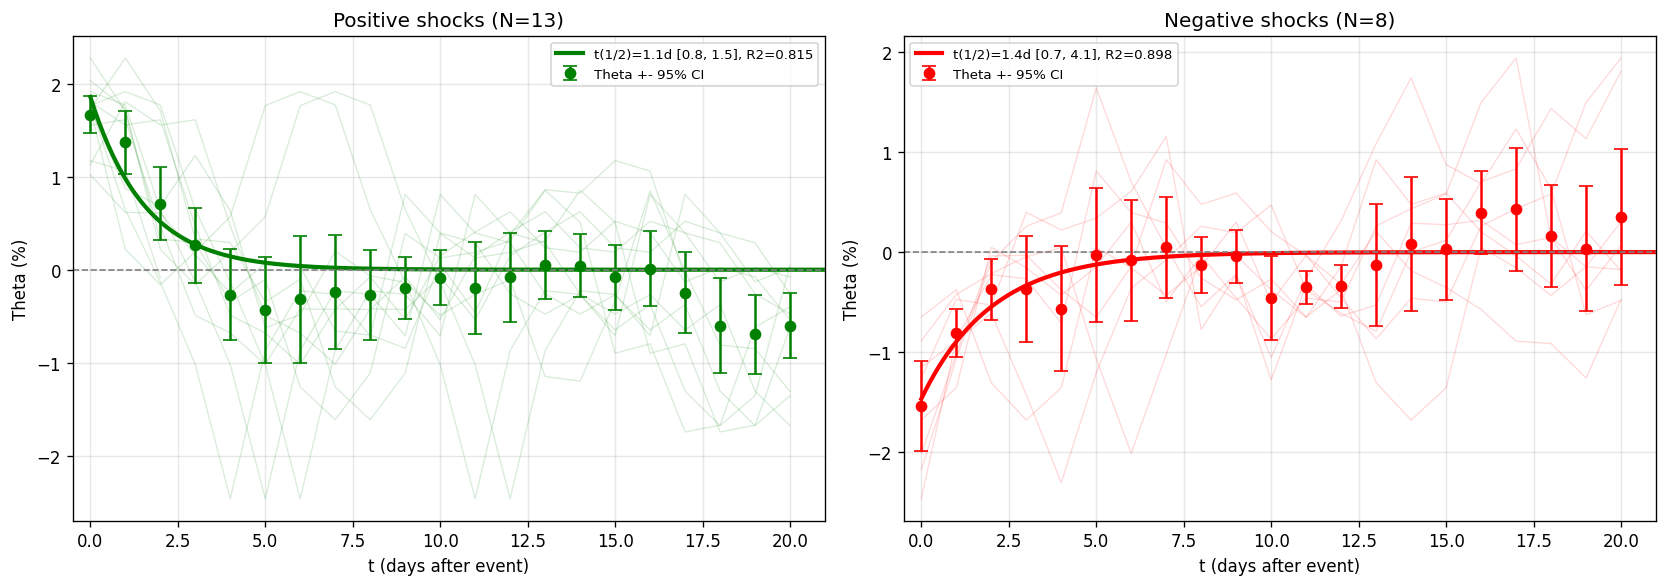

In [ ]:
tau_fine = np.linspace(0, 25, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (direction, color) in enumerate([('positive', 'green'), ('negative', 'red')]):
    if direction not in fit_by_direction:
        continue
    res = fit_by_direction[direction]
    avg = res['avg']
    ax = axes[idx]

    ax.errorbar(avg['tau'], avg['theta_mean'] * 100,
                yerr=1.96 * avg['theta_se'] * 100,
                fmt=f'{color[0]}o', ms=6, capsize=4, label='Theta +- 95% CI')

    y_fit = model_exp_decay(tau_fine, *res['popt']) * 100
    ax.plot(tau_fine, y_fit, f'{color[0]}-', lw=2.5,
            label=f"t(1/2)={res['half_life']:.1f}d [{res['boot_ci_hl'][0]:.1f}, "
                  f"{res['boot_ci_hl'][1]:.1f}], R2={res['r2']:.3f}")

    sub_events = dynamics_df[dynamics_df['direction'] == direction]
    for ed in sub_events['event_date'].unique():
        sub_e = sub_events[sub_events['event_date'] == ed]
        ax.plot(sub_e['tau'], sub_e['theta'] * 100,
                f'{color[0]}-', alpha=0.15, lw=0.8)

    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.set_xlabel('t (days after event)')
    ax.set_ylabel('Theta (%)')
    ax.set_xlim(-0.5, 21)
    title_dir = 'Positive shocks' if direction == 'positive' else 'Negative shocks'
    ax.set_title(f'{title_dir} (N={res["n_events"]})')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

POSITIVE (N=13):
  Theta(t) = +1.667% * exp(-0.606*t)
  Theta_0 = +1.667% (fixed from DML)
  Lambda  = 0.606  NLS SE=0.199  Boot SE=0.096  95% CI=[0.438, 0.817]
  t(1/2) = 1.1d  95% CI=[0.8, 1.6]
  R2 = 0.8062

NEGATIVE (N=8):
  Theta(t) = -1.534% * exp(-0.518*t)
  Theta_0 = -1.534% (fixed from DML)
  Lambda  = 0.518  NLS SE=0.079  Boot SE=0.211  95% CI=[0.203, 0.951]
  t(1/2) = 1.3d  95% CI=[0.7, 3.4]
  R2 = 0.8951



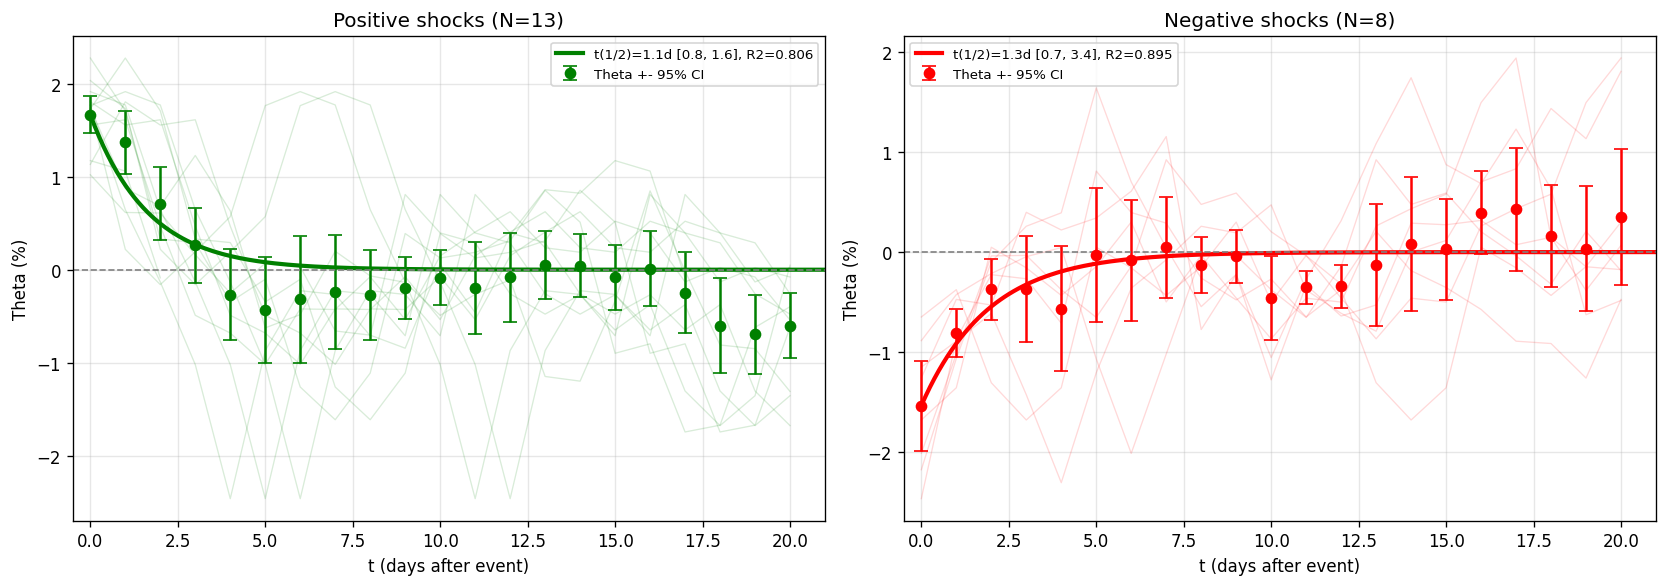

In [ ]:
FIT_HORIZON = 8

def model_exp_fixed_theta0(t, lam, theta0_fixed):
    return theta0_fixed * np.exp(-lam * t)

def bootstrap_lambda_by_events(sub_df, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    events = sub_df['event_date'].unique()
    n_events = len(events)

    boot_lambdas = []
    for _ in range(n_boot):
        boot_events = rng.choice(events, size=n_events, replace=True)
        boot_data = pd.concat([
            sub_df[sub_df['event_date'] == e] for e in boot_events
        ])
        boot_data = boot_data[boot_data['tau'] <= FIT_HORIZON]
        avg_boot = boot_data.groupby('tau')['theta'].mean()
        tau_b = avg_boot.index.values.astype(float)
        theta_b = avg_boot.values

        theta0_fixed = theta_b[0]

        try:
            popt_b, _ = curve_fit(
                lambda t, lam: theta0_fixed * np.exp(-lam * t),
                tau_b, theta_b,
                p0=[0.5], bounds=([0.01], [10.0]), maxfev=5000)
            boot_lambdas.append(popt_b[0])
        except:
            continue

    return np.array(boot_lambdas)


if 'direction' in dynamics_df.columns:
    dynamics_df = dynamics_df.drop(columns=['direction'])

event_signs = dynamics_df[dynamics_df['tau'] == 0][['event_date', 'theta']].copy()
event_signs['direction'] = np.where(event_signs['theta'] > 0, 'positive', 'negative')
dynamics_df = dynamics_df.merge(
    event_signs[['event_date', 'direction']], on='event_date', how='left')


fit_by_direction = {}

for direction in ['positive', 'negative']:
    sub = dynamics_df[dynamics_df['direction'] == direction].copy()
    n_events = sub['event_date'].nunique()
    if n_events < 3:
        continue

    avg_dir = sub.groupby('tau').agg(
        theta_mean=('theta', 'mean'),
        theta_se=('theta', lambda x: x.std() / np.sqrt(len(x))),
    ).reset_index()

    avg_fit = avg_dir[avg_dir['tau'] <= FIT_HORIZON]
    tau_d = avg_fit['tau'].values.astype(float)
    theta_d = avg_fit['theta_mean'].values

    theta0_real = theta_d[0]

    popt_d, pcov_d = curve_fit(
        lambda t, lam: theta0_real * np.exp(-lam * t),
        tau_d, theta_d,
        p0=[0.5], bounds=([0.01], [10.0]), maxfev=10000)

    lam_hat = popt_d[0]
    lam_se_nls = np.sqrt(pcov_d[0, 0])

    boot_lambdas = bootstrap_lambda_by_events(sub)
    boot_se = boot_lambdas.std()
    boot_ci_lam = np.percentile(boot_lambdas, [2.5, 97.5])
    boot_half_life = np.log(2) / boot_lambdas
    boot_ci_hl = np.percentile(boot_half_life, [2.5, 97.5])

    y_pred_d = theta0_real * np.exp(-lam_hat * tau_d)
    ss_res = np.sum((theta_d - y_pred_d) ** 2)
    ss_tot = np.sum((theta_d - theta_d.mean()) ** 2)
    r2_d = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    half_life_d = np.log(2) / lam_hat

    fit_by_direction[direction] = {
        'theta0': theta0_real,
        'lam': lam_hat, 'lam_se_nls': lam_se_nls,
        'boot_se': boot_se,
        'r2': r2_d, 'half_life': half_life_d,
        'n_events': n_events, 'avg': avg_dir,
        'boot_ci_lam': boot_ci_lam,
        'boot_ci_hl': boot_ci_hl,
    }

    print(f"{direction.upper()} (N={n_events}):")
    print(f"  Theta(t) = {theta0_real*100:+.3f}% * exp(-{lam_hat:.3f}*t)")
    print(f"  Theta_0 = {theta0_real*100:+.3f}% (fixed from DML)")
    print(f"  Lambda  = {lam_hat:.3f}  "
          f"NLS SE={lam_se_nls:.3f}  "
          f"Boot SE={boot_se:.3f}  "
          f"95% CI=[{boot_ci_lam[0]:.3f}, {boot_ci_lam[1]:.3f}]")
    print(f"  t(1/2) = {half_life_d:.1f}d  "
          f"95% CI=[{boot_ci_hl[0]:.1f}, {boot_ci_hl[1]:.1f}]")
    print(f"  R2 = {r2_d:.4f}")
    print()

# график
tau_fine = np.linspace(0, 25, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (direction, color) in enumerate([('positive', 'green'), ('negative', 'red')]):
    if direction not in fit_by_direction:
        continue
    res = fit_by_direction[direction]
    avg = res['avg']
    ax = axes[idx]

    ax.errorbar(avg['tau'], avg['theta_mean'] * 100,
                yerr=1.96 * avg['theta_se'] * 100,
                fmt=f'{color[0]}o', ms=6, capsize=4, label='Theta +- 95% CI')

    y_fit = res['theta0'] * np.exp(-res['lam'] * tau_fine) * 100
    ax.plot(tau_fine, y_fit, f'{color[0]}-', lw=2.5,
            label=f"t(1/2)={res['half_life']:.1f}d [{res['boot_ci_hl'][0]:.1f}, "
                  f"{res['boot_ci_hl'][1]:.1f}], R2={res['r2']:.3f}")

    sub_events = dynamics_df[dynamics_df['direction'] == direction]
    for ed in sub_events['event_date'].unique():
        sub_e = sub_events[sub_events['event_date'] == ed]
        ax.plot(sub_e['tau'], sub_e['theta'] * 100,
                f'{color[0]}-', alpha=0.15, lw=0.8)

    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.set_xlabel('t (days after event)')
    ax.set_ylabel('Theta (%)')
    ax.set_xlim(-0.5, 21)
    title_dir = 'Positive shocks' if direction == 'positive' else 'Negative shocks'
    ax.set_title(f'{title_dir} (N={res["n_events"]})')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()